# **Model: XGBoost**

In [8]:
!pip install -q xgboost

**1. Imports**

In [9]:
import os
import glob
import time
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

print("XGBoost version:", xgb.__version__)
print("Setup complete.")

XGBoost version: 3.4.1
Setup complete.


In [10]:
from google.colab import files

uploaded = files.upload()

Saving CIC-IDS2017.zip to CIC-IDS2017 (1).zip


**2. Extracting Files**

In [11]:
!mkdir -p /content/CIC-IDS2017
!unzip -q "/content/CIC-IDS2017.zip" -d "/content/CIC-IDS2017"

print("Dataset extracted.")

Dataset extracted.


In [12]:
parquet_files = glob.glob(
    "/content/CIC-IDS2017/**/*.parquet",
    recursive=True
)

print("Parquet files:", len(parquet_files))

for file in parquet_files:
    print(os.path.basename(file))

Parquet files: 8
DoS-Wednesday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
Benign-Monday-no-metadata.parquet
DDoS-Friday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet


**3. Loading Files**

In [13]:
dataframes = []

for file in parquet_files:
    temp = pd.read_parquet(file)

    print(
        os.path.basename(file),
        temp.shape
    )

    dataframes.append(temp)

df = pd.concat(dataframes, ignore_index=True)

del dataframes
gc.collect()

df.columns = df.columns.str.strip()

print("\nCombined:", df.shape)

DoS-Wednesday-no-metadata.parquet (584991, 78)
Portscan-Friday-no-metadata.parquet (119522, 78)
Benign-Monday-no-metadata.parquet (458831, 78)
DDoS-Friday-no-metadata.parquet (221264, 78)
Infiltration-Thursday-no-metadata.parquet (207630, 78)
Bruteforce-Tuesday-no-metadata.parquet (389714, 78)
Botnet-Friday-no-metadata.parquet (176038, 78)
WebAttacks-Thursday-no-metadata.parquet (155820, 78)

Combined: (2313810, 78)


**4. Cleaning Data**

In [14]:
print("Before:", df.shape)

df = df.drop_duplicates().copy()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().copy()

print("After:", df.shape)

Before: (2313810, 78)
After: (2231806, 78)


**5. Binary target**

In [15]:
df["Label"] = df["Label"].astype(str).str.strip()

df["Target"] = np.where(
    df["Label"].str.upper() == "BENIGN",
    0,
    1
)

print(df["Target"].value_counts())
print()
print(df["Target"].value_counts(normalize=True) * 100)

Target
0    1895314
1     336492
Name: count, dtype: int64

Target
0    84.922883
1    15.077117
Name: proportion, dtype: float64


In [16]:
X = df.drop(columns=["Label", "Target"])
y = df["Target"]

print("Features:", X.shape[1])
print("Non-numeric:", X.select_dtypes(exclude=[np.number]).columns.tolist())

Features: 77
Non-numeric: []


**6. Test/Train Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training: (1785444, 77)
Testing : (446362, 77)

Train distribution:
Target
0    1516251
1     269193
Name: count, dtype: int64

Test distribution:
Target
0    379063
1     67299
Name: count, dtype: int64


In [18]:
del df, X, y
gc.collect()

200

**7. Configure XGBoost**

In [19]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    tree_method="hist",

    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


**8. Handling Class Imbalance**

In [20]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("BENIGN training samples:", negative)
print("ATTACK training samples:", positive)
print("scale_pos_weight:", scale_pos_weight)

BENIGN training samples: 1516251
ATTACK training samples: 269193
scale_pos_weight: 5.632579599023749


In [21]:
xgb_model.set_params(
    scale_pos_weight=scale_pos_weight
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

**9. Train XGBoost**

In [22]:
start_time = time.time()

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

training_time = time.time() - start_time

print("\nXGBoost training complete.")
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

[0]	validation_0-logloss:0.60064
[1]	validation_0-logloss:0.52548
[2]	validation_0-logloss:0.46217
[3]	validation_0-logloss:0.40869
[4]	validation_0-logloss:0.36257
[5]	validation_0-logloss:0.32269
[6]	validation_0-logloss:0.28860
[7]	validation_0-logloss:0.25842
[8]	validation_0-logloss:0.23185
[9]	validation_0-logloss:0.20838
[10]	validation_0-logloss:0.18778
[11]	validation_0-logloss:0.16955
[12]	validation_0-logloss:0.15311
[13]	validation_0-logloss:0.13826
[14]	validation_0-logloss:0.12552
[15]	validation_0-logloss:0.11396
[16]	validation_0-logloss:0.10364
[17]	validation_0-logloss:0.09430
[18]	validation_0-logloss:0.08603
[19]	validation_0-logloss:0.07848
[20]	validation_0-logloss:0.07146
[21]	validation_0-logloss:0.06531
[22]	validation_0-logloss:0.05980
[23]	validation_0-logloss:0.05476
[24]	validation_0-logloss:0.05015
[25]	validation_0-logloss:0.04609
[26]	validation_0-logloss:0.04250
[27]	validation_0-logloss:0.03921
[28]	validation_0-logloss:0.03620
[29]	validation_0-loglos

**10. Evaluate XGBoost**

In [23]:
start_time = time.time()

y_pred = xgb_model.predict(X_test)

prediction_time = time.time() - start_time

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Sentinel XGBoost v1 ===")
print(f"Prediction Time: {prediction_time:.2f} seconds")
print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1 Score : {f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "ATTACK"],
        digits=6
    )
)

=== Sentinel XGBoost v1 ===
Prediction Time: 7.44 seconds
Accuracy : 0.999189
Precision: 0.995353
Recall   : 0.999287
F1 Score : 0.997316

Classification Report:
              precision    recall  f1-score   support

      BENIGN   0.999873  0.999172  0.999522    379063
      ATTACK   0.995353  0.999287  0.997316     67299

    accuracy                       0.999189    446362
   macro avg   0.997613  0.999229  0.998419    446362
weighted avg   0.999192  0.999189  0.999190    446362



**11. Confusion Matrix**

In [24]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"\nFalse Positive Rate: {false_positive_rate:.6f}")
print(f"False Negative Rate: {false_negative_rate:.6f}")

True Negatives : 378749
False Positives: 314
False Negatives: 48
True Positives : 67251

False Positive Rate: 0.000828
False Negative Rate: 0.000713


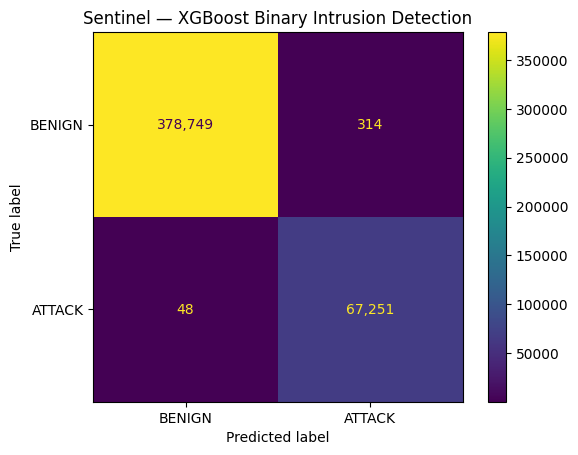

In [25]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format=",")
plt.title("Sentinel — XGBoost Binary Intrusion Detection")
plt.show()

**12. Further Inspection**

In [26]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(20))

,Feature,Importance
13,Bwd Packet Length Std,0.418019
61,Subflow Fwd Packets,0.114262
52,Avg Packet Size,0.108175
12,Bwd Packet Length Mean,0.077455
2,Total Fwd Packets,0.054812
46,PSH Flag Count,0.022532
6,Fwd Packet Length Max,0.012517
42,Packet Length Variance,0.011337
37,Bwd Packets/s,0.011262
47,ACK Flag Count,0.010996


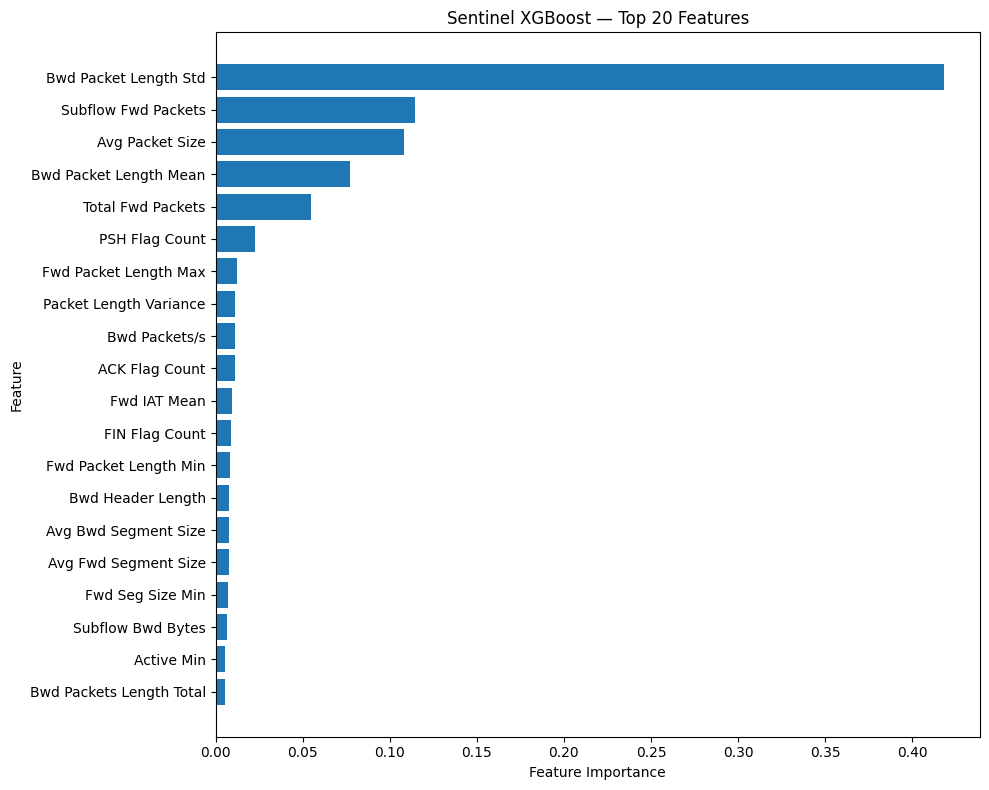

In [27]:
top_features = importance_df.head(20).sort_values("Importance")

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Sentinel XGBoost — Top 20 Features")
plt.tight_layout()
plt.show()

**13. Saving Results**

In [28]:
xgb_model.save_model(
    "/content/sentinel_xgboost_binary_v1.json"
)

import joblib

joblib.dump(
    X_train.columns.tolist(),
    "/content/sentinel_feature_columns_v1.joblib"
)

print("XGBoost model and feature schema saved.")

XGBoost model and feature schema saved.


In [29]:
from google.colab import files

files.download("/content/sentinel_xgboost_binary_v1.json")
files.download("/content/sentinel_feature_columns_v1.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>